In [1]:
!gdown 1nhcByJZtYLk5RAHOGzKf_SaaZDRNe3vB

Downloading...
From (original): https://drive.google.com/uc?id=1nhcByJZtYLk5RAHOGzKf_SaaZDRNe3vB
From (redirected): https://drive.google.com/uc?id=1nhcByJZtYLk5RAHOGzKf_SaaZDRNe3vB&confirm=t&uuid=3b723520-7860-4666-98be-7470c16214aa
To: /kaggle/working/Dataset.zip
100%|█████████████████████████████████████████| 224M/224M [00:01<00:00, 124MB/s]


In [2]:
!unzip /kaggle/working/Dataset.zip

Archive:  /kaggle/working/Dataset.zip
   creating: dataset/
   creating: dataset/Angry/
   creating: dataset/Disgust/
   creating: dataset/Fear/
   creating: dataset/Happy/
   creating: dataset/Neutral/
   creating: dataset/Pleasant_surprise/
   creating: dataset/Sad/
  inflating: dataset/Disgust/OAF_gap_disgust.wav  
  inflating: dataset/Disgust/OAF_jar_disgust.wav  
  inflating: dataset/Disgust/OAF_mill_disgust.wav  
  inflating: dataset/Disgust/OAF_pearl_disgust.wav  
  inflating: dataset/Disgust/YAF_beg_disgust.wav  
  inflating: dataset/Disgust/OAF_vine_disgust.wav  
  inflating: dataset/Disgust/OAF_pike_disgust.wav  
  inflating: dataset/Disgust/OAF_yes_disgust.wav  
  inflating: dataset/Disgust/OAF_size_disgust.wav  
  inflating: dataset/Disgust/YAF_time_disgust.wav  
  inflating: dataset/Disgust/YAF_jar_disgust.wav  
  inflating: dataset/Disgust/YAF_far_disgust.wav  
  inflating: dataset/Disgust/OAF_pain_disgust.wav  
  inflating: dataset/Disgust/OAF_boat_disgust.wav  
  inflat

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import seaborn as sns
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration parameters
class Config:
    base_folder = "/kaggle/working/dataset/"  # Replace with your dataset path
    sample_rate = 22050  # Standard sample rate
    n_mfcc = 13  # Number of MFCC features
    n_fft = 2048  # Size of FFT window
    hop_length = 512  # Hop length for MFCC extraction
    max_audio_length = 5  # Maximum audio length in seconds
    batch_size = 32
    learning_rate = 0.001
    num_epochs = 30
    hidden_size = 128
    num_layers = 2
    dropout = 0.3
    test_size = 0.2
    val_size = 0.1
    # Directories for saving outputs
    graphs_dir = "graphs"
    models_dir = "models"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()

# Create necessary directories if they don't exist
os.makedirs(config.graphs_dir, exist_ok=True)
os.makedirs(config.models_dir, exist_ok=True)

# Function to extract MFCC features from audio file
def extract_features(file_path, max_pad_len=None):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=config.sample_rate)
        
        # Calculate the maximum length to pad/truncate
        if max_pad_len is None:
            max_pad_len = config.sample_rate * config.max_audio_length
        
        # If audio is longer than max_pad_len, truncate it
        if len(audio) > max_pad_len:
            audio = audio[:max_pad_len]
        # If audio is shorter than max_pad_len, pad with zeros
        else:
            audio = np.pad(audio, (0, max_pad_len - len(audio)), 'constant')
        
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=config.n_mfcc,
                                    n_fft=config.n_fft, hop_length=config.hop_length)
        
        # Transpose to get time as the first dimension (time_steps, n_mfcc)
        mfccs = mfccs.T
        
        return mfccs
    except Exception as e:
        print(f"Error extracting features from {file_path}: {str(e)}")
        return None

# Custom Dataset class for audio data
class AudioDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        # Find the maximum sequence length for padding
        max_length = 0
        for file_path in file_paths:
            features = extract_features(file_path)
            if features is not None and features.shape[0] > max_length:
                max_length = features.shape[0]
        
        self.max_length = max_length
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Extract features from audio file
        features = extract_features(file_path)
        
        # Pad or truncate features to max_length
        if features.shape[0] < self.max_length:
            padding = np.zeros((self.max_length - features.shape[0], features.shape[1]))
            features = np.vstack((features, padding))
        elif features.shape[0] > self.max_length:
            features = features[:self.max_length, :]
        
        # Convert to tensor
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

# LSTM Model Definition
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))
        
        # Get the output from the last time step
        out = self.dropout(out[:, -1, :])
        
        # Pass through the fully connected layer
        out = self.fc(out)
        
        return out

# Function to collect file paths and labels
def collect_data(base_folder):
    file_paths = []
    labels = []
    label_names = []
    
    # Loop through each subdirectory (class label)
    for label_idx, label_name in enumerate(sorted(os.listdir(base_folder))):
        label_dir = os.path.join(base_folder, label_name)
        
        # Skip if not a directory
        if not os.path.isdir(label_dir):
            continue
        
        label_names.append(label_name)
        
        # Loop through each audio file in the directory
        for filename in os.listdir(label_dir):
            file_path = os.path.join(label_dir, filename)
            
            # Skip if not a file
            if not os.path.isfile(file_path):
                continue
            
            # Ensure it's an audio file (basic check)
            if filename.endswith(('.wav', '.mp3', '.ogg', '.flac')):
                file_paths.append(file_path)
                labels.append(label_idx)
    
    return file_paths, labels, label_names

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    model.to(device)
    
    best_val_acc = 0.0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for inputs, labels in train_loop:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            # Update progress bar
            train_loop.set_postfix(loss=loss.item(), accuracy=correct_train/total_train)
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)
        
        # Validation phase
        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for inputs, labels in val_loop:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
                # Update progress bar
                val_loop.set_postfix(loss=loss.item(), accuracy=correct_val/total_val)
        
        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
        
        # Save model at each epoch with epoch number
        model_save_path = os.path.join(config.models_dir, f"lstm_model_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_train_loss,
            'val_loss': epoch_val_loss,
            'train_acc': epoch_train_acc,
            'val_acc': epoch_val_acc
        }, model_save_path)
        print(f"Model saved for epoch {epoch+1} at {model_save_path}")
        
        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_path = os.path.join(config.models_dir, "best_lstm_model.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved with validation accuracy: {best_val_acc:.4f}")
        
        # Plot and save training progress after each epoch
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
            plot_training_progress(train_losses, val_losses, train_accs, val_accs, epoch + 1)
    
    # Return training history
    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accs,
        'val_acc': val_accs
    }
    
    return history

# Function to plot training progress during training
def plot_training_progress(train_losses, val_losses, train_accs, val_accs, current_epoch):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'Loss up to epoch {current_epoch}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.title(f'Accuracy up to epoch {current_epoch}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    progress_graph_path = os.path.join(config.graphs_dir, f'training_progress_epoch_{current_epoch}.png')
    plt.savefig(progress_graph_path)
    plt.close()

# Function to evaluate model
def evaluate_model(model, test_loader, device, label_names):
    model.eval()
    
    all_predictions = []
    all_labels = []
    class_correct = [0] * len(label_names)
    class_total = [0] * len(label_names)
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            
            # Collect predictions and true labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Calculate per-class accuracy
            c = (predictions == labels).squeeze()
            for i in range(len(labels)):
                label = labels[i].item()
                class_correct[label] += c[i].item()
                class_total[label] += 1
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')
    per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average=None)
    
    # Calculate per-class accuracy
    per_class_acc = [class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(len(label_names))]
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=label_names))
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Save per-class metrics
    per_class_metrics = {
        'accuracy': per_class_acc,
        'precision': per_class_precision.tolist(),
        'recall': per_class_recall.tolist(),
        'f1': per_class_f1.tolist(),
        'support': support.tolist() if isinstance(support, np.ndarray) else support
    }
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'predictions': all_predictions,
        'true_labels': all_labels,
        'per_class_metrics': per_class_metrics
    }

# Function to plot training history
def plot_training_history(history):
    # Plot training & validation loss
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.graphs_dir, 'final_training_history.png'))
    plt.close()

# Function to plot confusion matrix
def plot_confusion_matrix(confusion_matrix, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(config.graphs_dir, 'confusion_matrix.png'))
    plt.close()

# Function to plot evaluation metrics
def plot_evaluation_metrics(eval_results, label_names):
    # Plot overall metrics
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    values = [eval_results[metric] for metric in metrics]
    
    plt.figure(figsize=(10, 6))
    plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
    plt.title('Overall Evaluation Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(config.graphs_dir, 'overall_metrics.png'))
    plt.close()
    
    # Plot per-class metrics
    per_class_metrics = eval_results['per_class_metrics']
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
    
    plt.figure(figsize=(15, 10))
    x = np.arange(len(label_names))
    width = 0.2
    
    for i, metric in enumerate(metrics_to_plot):
        plt.bar(x + (i - 1.5) * width, per_class_metrics[metric], width, label=metric.capitalize())
    
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Per-Class Evaluation Metrics')
    plt.xticks(x, label_names, rotation=45, ha='right')
    plt.legend()
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(config.graphs_dir, 'per_class_metrics.png'))
    plt.close()

# Main function
def main():
    print(f"Using device: {config.device}")
    
    # Collect data
    print("Collecting data...")
    file_paths, labels, label_names = collect_data(config.base_folder)
    
    if len(file_paths) == 0:
        print(f"No audio files found in {config.base_folder}")
        return
    
    print(f"Found {len(file_paths)} audio files across {len(label_names)} classes")
    print(f"Classes: {label_names}")
    
    # Split into train, validation, and test sets
    train_val_files, test_files, train_val_labels, test_labels = train_test_split(
        file_paths, labels, test_size=config.test_size, stratify=labels, random_state=42
    )
    
    # Calculate validation size relative to the train+val set
    relative_val_size = config.val_size / (1 - config.test_size)
    
    train_files, val_files, train_labels, val_labels = train_test_split(
        train_val_files, train_val_labels, test_size=relative_val_size, 
        stratify=train_val_labels, random_state=42
    )
    
    print(f"Training set: {len(train_files)} samples")
    print(f"Validation set: {len(val_files)} samples")
    print(f"Test set: {len(test_files)} samples")
    
    # Create datasets
    print("Creating datasets...")
    train_dataset = AudioDataset(train_files, train_labels)
    val_dataset = AudioDataset(val_files, val_labels)
    test_dataset = AudioDataset(test_files, test_labels)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=4)
    
    # Get a sample batch to determine input size
    sample_batch, _ = next(iter(train_loader))
    input_size = sample_batch.shape[2]  # Number of features (n_mfcc)
    num_classes = len(label_names)
    
    print(f"Input size: {input_size}")
    print(f"Number of classes: {num_classes}")
    
    # Initialize model
    model = LSTMClassifier(
        input_size=input_size,
        hidden_size=config.hidden_size,
        num_layers=config.num_layers,
        num_classes=num_classes,
        dropout=config.dropout
    )
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    
    # Train model
    print("Starting training...")
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=config.num_epochs,
        device=config.device
    )
    
    # Load best model
    best_model_path = os.path.join(config.models_dir, "best_lstm_model.pth")
    model.load_state_dict(torch.load(best_model_path))
    
    # Save the full model including architecture
    full_model_path = os.path.join(config.models_dir, "full_lstm_model.pth")
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'class_names': label_names,
        'input_size': input_size,
        'hidden_size': config.hidden_size,
        'num_layers': config.num_layers,
        'num_classes': num_classes,
        'dropout': config.dropout
    }, full_model_path)
    
    print(f"Full model saved to {full_model_path}")
    
    # Evaluate model
    print("Evaluating model...")
    eval_results = evaluate_model(model, test_loader, config.device, label_names)
    
    # Plot training history
    print("Plotting training history...")
    plot_training_history(history)
    
    # Plot confusion matrix
    print("Plotting confusion matrix...")
    plot_confusion_matrix(eval_results['confusion_matrix'], label_names)
    
    # Plot evaluation metrics
    print("Plotting evaluation metrics...")
    plot_evaluation_metrics(eval_results, label_names)
    
    # Save evaluation metrics to file
    metrics_file_path = os.path.join(config.graphs_dir, "evaluation_metrics.txt")
    with open(metrics_file_path, "w") as f:
        f.write(f"Accuracy: {eval_results['accuracy']:.4f}\n")
        f.write(f"Precision: {eval_results['precision']:.4f}\n")
        f.write(f"Recall: {eval_results['recall']:.4f}\n")
        f.write(f"F1 Score: {eval_results['f1_score']:.4f}\n\n")
        
        f.write("Per-Class Metrics:\n")
        for i, class_name in enumerate(label_names):
            f.write(f"{class_name}:\n")
            f.write(f"  Accuracy: {eval_results['per_class_metrics']['accuracy'][i]:.4f}\n")
            f.write(f"  Precision: {eval_results['per_class_metrics']['precision'][i]:.4f}\n")
            f.write(f"  Recall: {eval_results['per_class_metrics']['recall'][i]:.4f}\n")
            f.write(f"  F1 Score: {eval_results['per_class_metrics']['f1'][i]:.4f}\n")
            if isinstance(eval_results['per_class_metrics']['support'], list):
                f.write(f"  Support: {eval_results['per_class_metrics']['support'][i]}\n\n")
    
    print(f"Evaluation metrics saved to {metrics_file_path}")
    print(f"All graphs saved to {config.graphs_dir}")
    print(f"All model checkpoints saved to {config.models_dir}")

if __name__ == "__main__":
    main()

Using device: cuda
Found 2800 audio files across 7 classes
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Pleasant_surprise', 'Sad']
Training set: 1960 samples
Validation set: 280 samples
Test set: 560 samples
Creating datasets...
Input size: 13
Number of classes: 7
Starting training...


Epoch 1/30 [Val]: 100%|██████████| 9/9 [00:01<00:00,  4.65it/s, accuracy=0.296, loss=1.94]


Epoch 1/30 - Train Loss: 1.8548, Train Acc: 0.2398 - Val Loss: 1.7832, Val Acc: 0.2964
Model saved for epoch 1 at models/lstm_model_epoch_1.pth
Best model saved with validation accuracy: 0.2964


Epoch 2/30 [Val]: 100%|██████████| 9/9 [00:02<00:00,  4.24it/s, accuracy=0.461, loss=1.68]


Epoch 2/30 - Train Loss: 1.4111, Train Acc: 0.4122 - Val Loss: 1.5493, Val Acc: 0.4607
Model saved for epoch 2 at models/lstm_model_epoch_2.pth
Best model saved with validation accuracy: 0.4607


...

Epoch 30/30 - Train Loss: 0.4191, Train Acc: 0.8327 - Val Loss: 0.4950, Val Acc: 0.8179
Model saved for epoch 30 at models/lstm_model_epoch_30.pth


/tmp/ipykernel_31/1926363685.py:541: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Full model saved to models/full_lstm_model.pth
Evaluating model...


Evaluating: 100%|██████████| 18/18 [00:03<00:00,  5.37it/s]


Test Accuracy: 0.8821
Test Precision: 0.8955
Test Recall: 0.8821
Test F1 Score: 0.8793

Classification Report:
                   precision    recall  f1-score   support

            Angry       0.94      0.99      0.96        80
          Disgust       0.95      0.68      0.79        80
             Fear       0.92      0.96      0.94        80
            Happy       0.92      0.95      0.93        80
          Neutral       0.78      1.00      0.87        80
Pleasant_surprise       0.77      0.89      0.83        80
              Sad       1.00      0.71      0.83        80

         accuracy                           0.88       560
        macro avg       0.90      0.88      0.88       560
     weighted avg       0.90      0.88      0.88       560

Plotting training history...
Plotting confusion matrix...
Plotting evaluation metrics...
Evaluation metrics saved to graphs/evaluation_metrics.txt
All graphs saved to graphs
All model checkpoints saved to models


In [4]:
import zipfile
import os

def zip_folder(folder_path, output_zip_path):
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)  # relative path inside the zip
                zipf.write(file_path, arcname)
    print(f"Folder '{folder_path}' zipped to '{output_zip_path}'")

# Example usage
zip_folder('/kaggle/working/graphs', 'output.zip')


Folder '/kaggle/working/graphs' zipped to 'output.zip'


In [5]:
import zipfile
import os

def zip_folder(folder_path, output_zip_path):
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)  # relative path inside the zip
                zipf.write(file_path, arcname)
    print(f"Folder '{folder_path}' zipped to '{output_zip_path}'")

# Example usage
zip_folder('/kaggle/working/models', 'output_models.zip')


Folder '/kaggle/working/models' zipped to 'output_models.zip'


/tmp/ipykernel_31/769852423.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=config.device)


Using device: cuda
Loading model from /kaggle/working/models/full_lstm_model.pth...
Model loaded successfully.
Class labels: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Pleasant_surprise', 'Sad']


Enter the path to the audio file for prediction (or press Enter to exit):  /kaggle/working/dataset/Angry/OAF_back_angry.wav


Predicting emotion for /kaggle/working/dataset/Angry/OAF_back_angry.wav...
Predicted emotion: Angry
Confidence: 0.8137

Probabilities for all emotions:
Angry: 0.8137
Disgust: 0.0104
Fear: 0.0428
Happy: 0.1259
Neutral: 0.0003
Pleasant_surprise: 0.0067
Sad: 0.0003


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


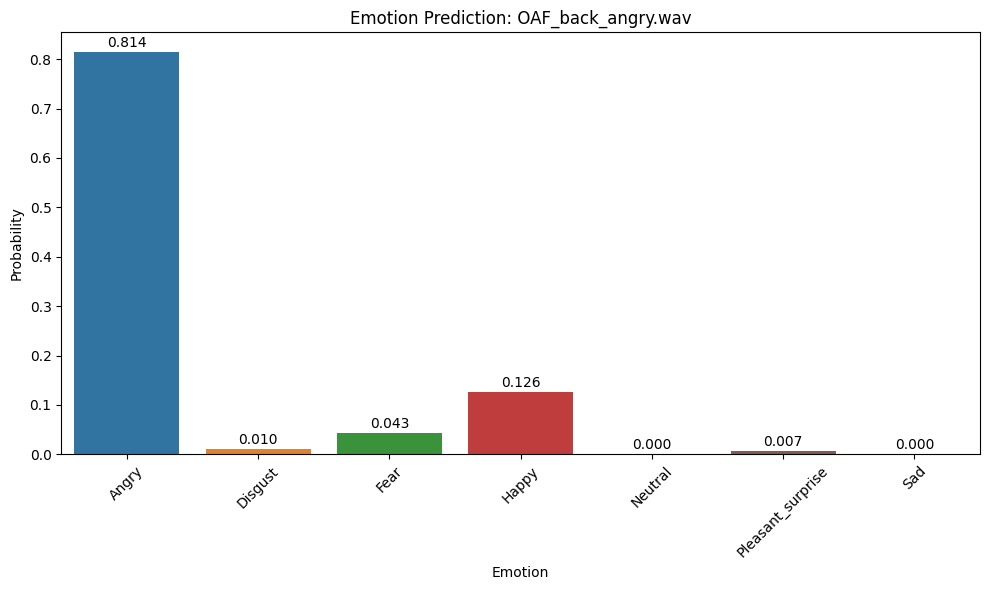


Enter the path to the audio file for prediction (or press Enter to exit):  


Done!


In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configuration
class Config:
    sample_rate = 22050  # Standard sample rate
    n_mfcc = 13  # Number of MFCC features
    n_fft = 2048  # Size of FFT window
    hop_length = 512  # Hop length for MFCC extraction
    max_audio_length = 5  # Maximum audio length in seconds
    hidden_size = 128
    num_layers = 2
    dropout = 0.3
    models_dir = "/kaggle/working/models"  # Directory where models are saved
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()

# Class labels
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Pleasant_surprise', 'Sad']

# LSTM Model Definition (same as in training code)
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))
        
        # Get the output from the last time step
        out = self.dropout(out[:, -1, :])
        
        # Pass through the fully connected layer
        out = self.fc(out)
        
        return out

# Function to extract MFCC features from audio file (same as in training code)
def extract_features(file_path, max_pad_len=None):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=config.sample_rate)
        
        # Calculate the maximum length to pad/truncate
        if max_pad_len is None:
            max_pad_len = config.sample_rate * config.max_audio_length
        
        # If audio is longer than max_pad_len, truncate it
        if len(audio) > max_pad_len:
            audio = audio[:max_pad_len]
        # If audio is shorter than max_pad_len, pad with zeros
        else:
            audio = np.pad(audio, (0, max_pad_len - len(audio)), 'constant')
        
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=config.n_mfcc,
                                    n_fft=config.n_fft, hop_length=config.hop_length)
        
        # Transpose to get time as the first dimension (time_steps, n_mfcc)
        mfccs = mfccs.T
        
        return mfccs
    except Exception as e:
        print(f"Error extracting features from {file_path}: {str(e)}")
        return None

# Function to load model from file
def load_model(model_path):
    try:
        # Load the full model checkpoint
        checkpoint = torch.load(model_path, map_location=config.device)
        
        # Check if it's a state_dict or full checkpoint
        if 'model_state_dict' in checkpoint:
            # It's a full checkpoint
            input_size = checkpoint.get('input_size', config.n_mfcc)
            hidden_size = checkpoint.get('hidden_size', config.hidden_size)
            num_layers = checkpoint.get('num_layers', config.num_layers)
            num_classes = checkpoint.get('num_classes', len(class_labels))
            dropout = checkpoint.get('dropout', config.dropout)
            
            # Initialize model with parameters from checkpoint
            model = LSTMClassifier(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                num_classes=num_classes,
                dropout=dropout
            )
            
            # Load the state dictionary
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            # It's just a model state dict (like best_lstm_model.pth)
            # Default to the n_mfcc as input size
            model = LSTMClassifier(
                input_size=config.n_mfcc,
                hidden_size=config.hidden_size,
                num_layers=config.num_layers,
                num_classes=len(class_labels),
                dropout=config.dropout
            )
            model.load_state_dict(checkpoint)
            
        model.to(config.device)
        model.eval()  # Set to evaluation mode
        return model
    
    except Exception as e:
        print(f"Error loading model from {model_path}: {str(e)}")
        return None

# Function to predict emotion for a single audio file
def predict_emotion(model, audio_path, max_length=None):
    # Extract features
    features = extract_features(audio_path)
    
    if features is None:
        return None, None, None
    
    # Handle padding if needed
    if max_length is not None:
        if features.shape[0] < max_length:
            padding = np.zeros((max_length - features.shape[0], features.shape[1]))
            features = np.vstack((features, padding))
        elif features.shape[0] > max_length:
            features = features[:max_length, :]
    
    # Convert to tensor and add batch dimension
    features_tensor = torch.FloatTensor(features).unsqueeze(0).to(config.device)
    
    # Get prediction
    with torch.no_grad():
        outputs = model(features_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_idx = torch.argmax(probabilities, dim=1).item()
        
    # Get class label and probability
    predicted_label = class_labels[predicted_idx]
    confidence = probabilities[0][predicted_idx].item()
    
    # Get all class probabilities
    all_probs = probabilities[0].cpu().numpy()
    
    return predicted_label, confidence, all_probs

# Function to predict emotions for multiple audio files
def predict_emotions_batch(model, audio_paths, max_length=None):
    results = []
    
    for audio_path in tqdm(audio_paths, desc="Predicting emotions"):
        predicted_label, confidence, all_probs = predict_emotion(model, audio_path, max_length)
        
        if predicted_label is not None:
            results.append({
                'file': os.path.basename(audio_path),
                'predicted_emotion': predicted_label,
                'confidence': confidence,
                'probabilities': {class_labels[i]: float(all_probs[i]) for i in range(len(class_labels))}
            })
    
    return results

# Function to visualize prediction probabilities
def plot_prediction_probabilities(probabilities, title="Emotion Prediction Probabilities"):
    plt.figure(figsize=(10, 6))
    
    # Create bar chart
    sns.barplot(x=list(probabilities.keys()), y=list(probabilities.values()))
    
    # Add labels and title
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Probability")
    plt.xticks(rotation=45)
    
    # Add value labels on top of bars
    for i, v in enumerate(probabilities.values()):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    
    plt.tight_layout()
    plt.show()

# Main function for prediction
def main():
    print(f"Using device: {config.device}")
    
    # Path to the model (change as needed)
    model_path = os.path.join(config.models_dir, "full_lstm_model.pth")
    
    # Check if model exists
    if not os.path.exists(model_path):
        print(f"Model not found at {model_path}. Please check the path.")
        # Try to find best model
        best_model_path = os.path.join(config.models_dir, "best_lstm_model.pth")
        if os.path.exists(best_model_path):
            print(f"Found best model at {best_model_path}. Using this instead.")
            model_path = best_model_path
        else:
            # Try to find any model in the models directory
            model_files = [f for f in os.listdir(config.models_dir) if f.endswith('.pth')]
            if model_files:
                model_path = os.path.join(config.models_dir, model_files[0])
                print(f"Using model {model_path} instead.")
            else:
                print("No models found. Please train a model first.")
                return
    
    # Load the model
    print(f"Loading model from {model_path}...")
    model = load_model(model_path)
    
    if model is None:
        print("Failed to load model. Exiting.")
        return
    
    print("Model loaded successfully.")
    print(f"Class labels: {class_labels}")
    
    # Sample usage with a single file
    # Replace this with the path to your audio file
    audio_file = input("Enter the path to the audio file for prediction (or press Enter to exit): ")
    
    while audio_file.strip():
        if not os.path.exists(audio_file):
            print(f"File not found: {audio_file}")
        else:
            print(f"Predicting emotion for {audio_file}...")
            predicted_label, confidence, all_probs = predict_emotion(model, audio_file)
            
            if predicted_label is None:
                print("Prediction failed.")
            else:
                print(f"Predicted emotion: {predicted_label}")
                print(f"Confidence: {confidence:.4f}")
                
                # Display all probabilities
                print("\nProbabilities for all emotions:")
                probs_dict = {class_labels[i]: float(all_probs[i]) for i in range(len(class_labels))}
                for emotion, prob in probs_dict.items():
                    print(f"{emotion}: {prob:.4f}")
                
                # Plot the probabilities
                plot_prediction_probabilities(probs_dict, f"Emotion Prediction: {os.path.basename(audio_file)}")
        
        # Get next file
        audio_file = input("\nEnter the path to the audio file for prediction (or press Enter to exit): ")
    
    print("Done!")

# For batch prediction of multiple files in a directory
def predict_directory(model, directory_path, output_file=None):
    if not os.path.isdir(directory_path):
        print(f"Directory not found: {directory_path}")
        return
    
    # Get all audio files in the directory
    audio_extensions = ['.wav', '.mp3', '.ogg', '.flac']
    audio_files = [
        os.path.join(directory_path, f) for f in os.listdir(directory_path)
        if os.path.isfile(os.path.join(directory_path, f)) and 
        any(f.lower().endswith(ext) for ext in audio_extensions)
    ]
    
    if not audio_files:
        print(f"No audio files found in {directory_path}")
        return
    
    print(f"Found {len(audio_files)} audio files. Processing...")
    results = predict_emotions_batch(model, audio_files)
    
    # Output results
    print("\nPrediction Results:")
    for result in results:
        print(f"File: {result['file']}")
        print(f"Predicted Emotion: {result['predicted_emotion']}")
        print(f"Confidence: {result['confidence']:.4f}")
        print("-" * 30)
    
    # Save results to file if requested
    if output_file:
        import json
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=4)
        print(f"Results saved to {output_file}")

# Example usage
if __name__ == "__main__":
    main()
    
